<a href="https://colab.research.google.com/github/avvannavaraniket/Darkship_detection/blob/main/ship_detection_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os

project_path = "/content/drive/MyDrive/DarkShipProject"
os.makedirs(project_path, exist_ok=True)

print("Project folder created!")

Project folder created!


In [7]:
!pip install ultralytics
!pip install kaggle

In [8]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"aniketca","key":"373f528be0c0d43506015c7a0f3ef664"}'}

In [9]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                     Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           7350        179                1  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          13662        307                1  
meruvakodandasuraj/youtube-trending-videos-20202026                YouTube Trending Videos 2020–2026                       843930  2026-04-13 11:10:04.770000            501         25     

In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [12]:
!kaggle datasets download -d petrarodriguez/ls-ssdd-v1-0

Dataset URL: https://www.kaggle.com/datasets/petrarodriguez/ls-ssdd-v1-0
License(s): apache-2.0
ls-ssdd-v1-0.zip: Skipping, found more recently modified local copy (use --force to force download)


In [13]:
import zipfile

zip_path = "ls-ssdd-v1-0.zip"
extract_path = "/content/datasets"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [9]:
import zipfile

zip_path = "ls-ssdd-v1-0.zip"
extract_path = "/content/drive/MyDrive/DarkShipProject/datasets"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

KeyboardInterrupt: 

In [14]:
import os

dataset_path = "/content/drive/MyDrive/DarkShipProject/datasets"

print(os.listdir(dataset_path))

['Annotations_sub', 'JPEGImages_sub_test', 'JPEGImages_sub_train']


In [15]:
import os

img_path = os.path.join(dataset_path, "JPEGImages_sub_train", "JPEGImages_sub_train")

print(len(os.listdir(img_path)))

3634


(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

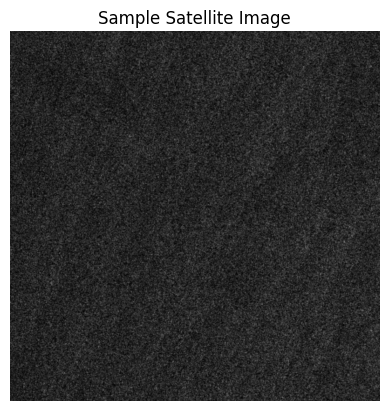

In [16]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/DarkShipProject/datasets"

img_path = os.path.join(dataset_path, "JPEGImages_sub_train", "JPEGImages_sub_train")

# get only image files
files = [f for f in os.listdir(img_path) if f.endswith(".jpg")]

sample_img = files[0]

img = Image.open(os.path.join(img_path, sample_img))

plt.imshow(img)
plt.title("Sample Satellite Image")
plt.axis('off')

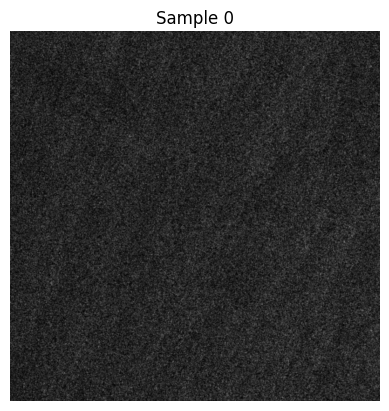

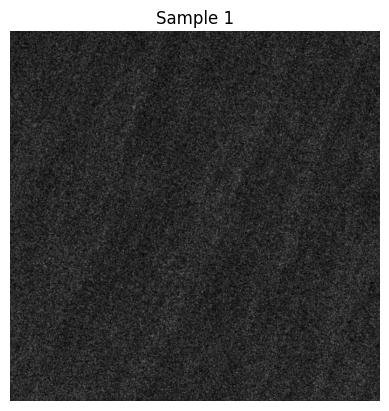

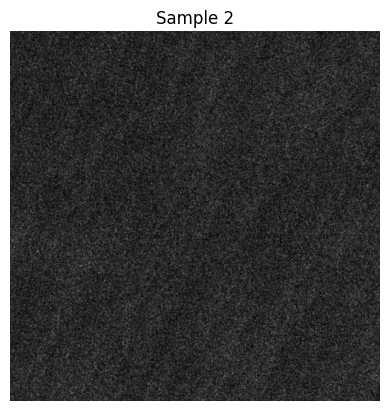

In [17]:
for i in range(3):
    sample_img = files[i]
    img = Image.open(os.path.join(img_path, sample_img))

    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title(f"Sample {i}")
    plt.axis('off')

In [18]:
ann_path = os.path.join(dataset_path, "Annotations_sub", "Annotations_sub")


In [19]:
import os

ann_path = os.path.join(dataset_path, "Annotations_sub", "Annotations_sub")

# get xml files
ann_files = [f for f in os.listdir(ann_path) if f.endswith(".xml")]

print("Total annotation files:", len(ann_files))

sample_ann = ann_files[0]

print("Sample annotation:", sample_ann)

# read file
with open(os.path.join(ann_path, sample_ann), "r") as f:
    content = f.read()

print(content[:500])

Total annotation files: 9000
Sample annotation: 03_17_25.xml
<?xml version="1.0" ?><annotation verified="no">
  <folder>JPEGImages</folder>
  <filename>03_17_25.xml</filename>
  <path>VOCdevkit/VOC2012/JPEGImages/03_17_25.xml</path>
  <source>
    <database>Unknown</database>
  </source>
  <size>
    <width>800</width>
    <height>800</height>
    <depth>1</depth>
  </size>
  <segmented>0</segmented>
</annotation>


In [20]:
import os

yolo_path = "/content/drive/MyDrive/DarkShipProject/yolo_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(yolo_path, folder), exist_ok=True)

print("YOLO folder structure created!")

YOLO folder structure created!


In [21]:
import xml.etree.ElementTree as ET

def convert_xml_to_yolo(xml_file, img_w, img_h):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
    except:
        return []   # skip bad XML

    yolo_labels = []

    for obj in root.findall("object"):
        cls = 0  # ship

        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        xmax = int(bbox.find("xmax").text)
        ymin = int(bbox.find("ymin").text)
        ymax = int(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        yolo_labels.append(f"{cls} {x_center} {y_center} {width} {height}")

    return yolo_labels

In [22]:
import shutil
from PIL import Image

images_path = os.path.join(dataset_path, "JPEGImages_sub_train", "JPEGImages_sub_train")
annotations_path = os.path.join(dataset_path, "Annotations_sub", "Annotations_sub")

image_files = [f for f in os.listdir(images_path) if f.endswith(".jpg")]

split_ratio = 0.8
split_index = int(len(image_files) * split_ratio)

train_files = image_files[:split_index]
val_files = image_files[split_index:]

In [23]:
def process_files(file_list, split_type):
    for img_file in file_list:
        img_full_path = os.path.join(images_path, img_file)

        # corresponding XML file
        xml_file = img_file.replace(".jpg", ".xml")
        xml_full_path = os.path.join(annotations_path, xml_file)

        if not os.path.exists(xml_full_path):
            continue

        # get image size
        img = Image.open(img_full_path)
        img_width, img_height = img.size

        # convert annotations
        yolo_labels = convert_xml_to_yolo(xml_full_path, img_width, img_height)

        # save label file
        label_file = img_file.replace(".jpg", ".txt")
        label_path = os.path.join(yolo_path, "labels", split_type, label_file)

        with open(label_path, "w") as f:
            f.write("\n".join(yolo_labels))

        # copy image
        dest_img_path = os.path.join(yolo_path, "images", split_type, img_file)
        shutil.copy(img_full_path, dest_img_path)

In [24]:
!ls /content

 datasets  'kaggle (1).json'   ls-ssdd-v1-0.zip   yolov8n.pt
 drive	    kaggle.json        sample_data


In [26]:
train_files = train_files[:2000]
val_files = val_files[:500]

In [27]:
process_files(train_files, "train")
process_files(val_files, "val")

print("Conversion complete!")

Conversion complete!


In [28]:
!ls /content/yolo_dataset

ls: cannot access '/content/yolo_dataset': No such file or directory


In [29]:
print(os.listdir(os.path.join(yolo_path, "labels/train"))[:5])


['05_17_5.txt', '05_17_6.txt', '05_17_7.txt', '05_17_8.txt', '05_17_9.txt']


In [30]:
sample_label = os.listdir(os.path.join(yolo_path, "labels/train"))[1]

with open(os.path.join(yolo_path, "labels/train", sample_label)) as f:
    print(f.read())

In [31]:
sample_img = os.listdir(os.path.join(yolo_path, "images/train"))[1]

print(sample_img.replace(".jpg", ".txt"))

05_17_5.txt


In [32]:
import os

label_path = os.path.join(yolo_path, "labels/train")

files = os.listdir(label_path)[:5]

for file in files:
    print("\nFile:", file)
    with open(os.path.join(label_path, file), "r") as f:
        print(f.read())


File: 05_17_5.txt


File: 05_17_6.txt


File: 05_17_7.txt


File: 05_17_8.txt


File: 05_17_9.txt



In [33]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

In [34]:
filtered_train_images = []
filtered_train_labels = []

label_path = os.path.join(yolo_path, "labels/train")
image_path = os.path.join(yolo_path, "images/train")

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file)) as f:
        if f.read().strip() != "":
            filtered_train_labels.append(file)
            filtered_train_images.append(file.replace(".txt", ".jpg"))

print("Filtered samples:", len(filtered_train_images))

Filtered samples: 402


In [35]:
empty_images = []

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file)) as f:
        if f.read().strip() == "":
            empty_images.append(file.replace(".txt", ".jpg"))

print("Total empty images:", len(empty_images))

Total empty images: 1664


In [36]:
import random

selected_empty = random.sample(empty_images, len(filtered_train_images))

print("Selected empty images:", len(selected_empty))

Selected empty images: 402


In [37]:
final_images = filtered_train_images + selected_empty
final_labels = filtered_train_labels + [img.replace(".jpg", ".txt") for img in selected_empty]

print("Final dataset size:", len(final_images))

Final dataset size: 804


In [38]:
balanced_path = yolo_path + "/balanced"

import os
os.makedirs(balanced_path + "/images/train", exist_ok=True)
os.makedirs(balanced_path + "/labels/train", exist_ok=True)

In [39]:
import shutil

for img, lbl in zip(final_images, final_labels):

    shutil.copy(
        os.path.join(image_path, img),
        os.path.join(balanced_path, "images/train", img)
    )

    shutil.copy(
        os.path.join(label_path, lbl),
        os.path.join(balanced_path, "labels/train", lbl)
    )

print("Balanced dataset created!")

Balanced dataset created!


In [40]:
import random

all_images = os.listdir(balanced_path + "/images/train")
random.shuffle(all_images)

split = int(0.8 * len(all_images))

train_imgs = all_images[:split]
val_imgs = all_images[split:]

os.makedirs(balanced_path + "/images/val", exist_ok=True)
os.makedirs(balanced_path + "/labels/val", exist_ok=True)

for img in val_imgs:
    lbl = img.replace(".jpg", ".txt")

    shutil.move(
        os.path.join(balanced_path, "images/train", img),
        os.path.join(balanced_path, "images/val", img)
    )

    shutil.move(
        os.path.join(balanced_path, "labels/train", lbl),
        os.path.join(balanced_path, "labels/val", lbl)
    )

print("Split done!")

Split done!


In [41]:
data_yaml = f"""
path: {balanced_path}

train: images/train
val: images/val

names:
  0: ship
"""

with open(balanced_path + "/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created!")

data.yaml created!


In [43]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=balanced_path + "/data.yaml",
    epochs=10,
    imgsz=512,
    batch=8
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DarkShipProject/yolo_dataset/balanced/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimize

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78a0557d3500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [44]:
print(balanced_path)

/content/drive/MyDrive/DarkShipProject/yolo_dataset/balanced


In [42]:
model = YOLO("yolov8s.pt")

model.train(
    data=balanced_path + "/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DarkShipProject/yolo_dataset/balanced/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimize

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783d3c207530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [44]:
import shutil

shutil.copy(
    "/content/runs/detect/train/weights/best.pt",
    "/content/drive/MyDrive/best_balanced_model.pt"
)

'/content/drive/MyDrive/best_balanced_model.pt'

In [45]:
import os
os.path.exists("/content/drive/MyDrive/best_balanced_model.pt")

True

In [46]:
shutil.copytree(
    "/content/runs/detect/train",
    "/content/drive/MyDrive/yolo_training_results",
    dirs_exist_ok=True
)

'/content/drive/MyDrive/yolo_training_results'

In [48]:
shutil.copytree(
    "/content/drive/MyDrive/DarkShipProject/yolo_dataset/balanced",
    "/content/drive/MyDrive/yolo_dataset_balanced_backup",
    dirs_exist_ok=True
)

'/content/drive/MyDrive/yolo_dataset_balanced_backup'

In [49]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best_balanced_model.pt")

In [51]:
import os

test_img = os.listdir("/content/datasets/JPEGImages_sub_test")[0]
test_path = os.path.join("/content/datasets/JPEGImages_sub_test", test_img)

print(test_path)

/content/datasets/JPEGImages_sub_test/JPEGImages_sub_test


In [57]:
import os

folder = "/content/datasets/JPEGImages_sub_test/JPEGImages_sub_test"

img = os.listdir(folder)[0]   # pick one image
img_path = os.path.join(folder, img)

print(img_path)  # sanity check

results = model.predict(
    source=img_path,   # ✅ now this is ONE image
    conf=0.15,
    save=True
)

/content/datasets/JPEGImages_sub_test/JPEGImages_sub_test/11_14_16.jpg

image 1/1 /content/datasets/JPEGImages_sub_test/JPEGImages_sub_test/11_14_16.jpg: 640x640 3 ships, 16.2ms
Speed: 3.6ms preprocess, 16.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

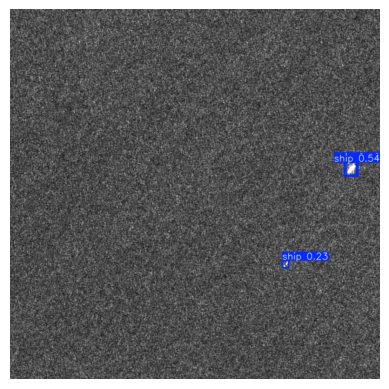

In [58]:
from PIL import Image
import matplotlib.pyplot as plt

output = "/content/runs/detect/predict/" + img
img = Image.open(output)

plt.imshow(img)
plt.axis("off")

In [59]:
for i in range(5):
    img = os.listdir(folder)[i]
    img_path = os.path.join(folder, img)

    print("Testing:", img)

    model.predict(
        source=img_path,
        conf=0.15,
        save=True
    )

Testing: 11_14_16.jpg

image 1/1 /content/datasets/JPEGImages_sub_test/JPEGImages_sub_test/11_14_16.jpg: 640x640 3 ships, 16.3ms
Speed: 3.7ms preprocess, 16.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Testing: 11_13_29.jpg

image 1/1 /content/datasets/JPEGImages_sub_test/JPEGImages_sub_test/11_13_29.jpg: 640x640 14 ships, 16.2ms
Speed: 2.7ms preprocess, 16.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Testing: 12_18_23.jpg

image 1/1 /content/datasets/JPEGImages_sub_test/JPEGImages_sub_test/12_18_23.jpg: 640x640 (no detections), 16.2ms
Speed: 2.6ms preprocess, 16.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Testing: 11_14_21.jpg

image 1/1 /content/datasets/JPEGImages_sub_test/JPEGImages_sub_test/11_14_21.jpg: 640x640 (no detections), 16.1ms
Speed: 2.6ms preprocess, 16.1ms infere